# GenAI-Powered Customer Insight Tool
### Turning raw product reviews into structured, actionable insights using an LLM

**Business context:** Product and planning teams don't have time to read thousands of reviews.
This notebook builds a pipeline that takes raw Amazon product reviews and produces, per product,
a structured insight card — top praises, top complaints, recurring themes, and a one-line
recommended action — generated by an LLM rather than hand-written rules.

**Dataset:** Amazon consumer electronics reviews (~34,600 reviews across 48 products — Kindle/Fire
tablets, Echo devices, batteries, etc.)

**Pipeline:**
1. Load & clean review data
2. EDA — rating distribution, review volume by product
3. Classical NLP baseline — VADER sentiment scoring (fast, free, no LLM needed)
4. GenAI layer — LLM-generated structured insight cards per product (themes, pros, cons, recommended action)
5. Compare classical sentiment vs. LLM-extracted themes
6. Export insight cards (used by the companion Streamlit dashboard)

**On the LLM provider:** this notebook is wired to **Groq** (`https://groq.com`), which offers a
genuinely free, permanent, no-credit-card API tier (14,400 requests/day) serving fast open-weight
models via an OpenAI-compatible API. Get a free key at **console.groq.com → API Keys**.

**Offline fallback:** if no `GROQ_API_KEY` is set, every LLM-dependent cell below automatically
falls back to a lightweight keyword-frequency summary so the notebook still runs end-to-end for
review/demo purposes. Set the key to get real LLM-generated insight cards.


## 1. Setup & Data Loading

In [1]:
import os
import json
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("../data/amazon_reviews.csv", low_memory=False)
print(df.shape)
df[["name", "reviews.rating", "reviews.text"]].head(3)


(34660, 21)


,name,reviews.rating,reviews.text
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,This product so far has not disappointed. My c...
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,great for beginner or experienced person. Boug...
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Inexpensive tablet for him to use and learn on...


## 2. Data Cleaning
Keep only the columns we need, drop rows with missing review text, and shorten product names
for readability in charts.

In [2]:
cols = ["name", "brand", "reviews.rating", "reviews.text", "reviews.title", "reviews.date"]
reviews = df[cols].copy()
reviews.columns = ["product", "brand", "rating", "text", "title", "date"]

reviews = reviews.dropna(subset=["text", "rating"]).copy()
reviews["rating"] = reviews["rating"].astype(int)

# Shorten product names for display (they're long, comma-separated marketing titles)
reviews["product_short"] = reviews["product"].str.split(",").str[0].str.slice(0, 40)

print("Reviews after cleaning:", len(reviews))
print("Unique products:", reviews["product_short"].nunique())
reviews.head(3)


Reviews after cleaning: 34626
Unique products: 36


,product,brand,rating,text,title,date,product_short
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,This product so far has not disappointed. My c...,Kindle,2017-01-13T00:00:00.000Z,All-New Fire HD 8 Tablet
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,great for beginner or experienced person. Boug...,very fast,2017-01-13T00:00:00.000Z,All-New Fire HD 8 Tablet
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,2017-01-13T00:00:00.000Z,All-New Fire HD 8 Tablet


## 3. Exploratory Data Analysis

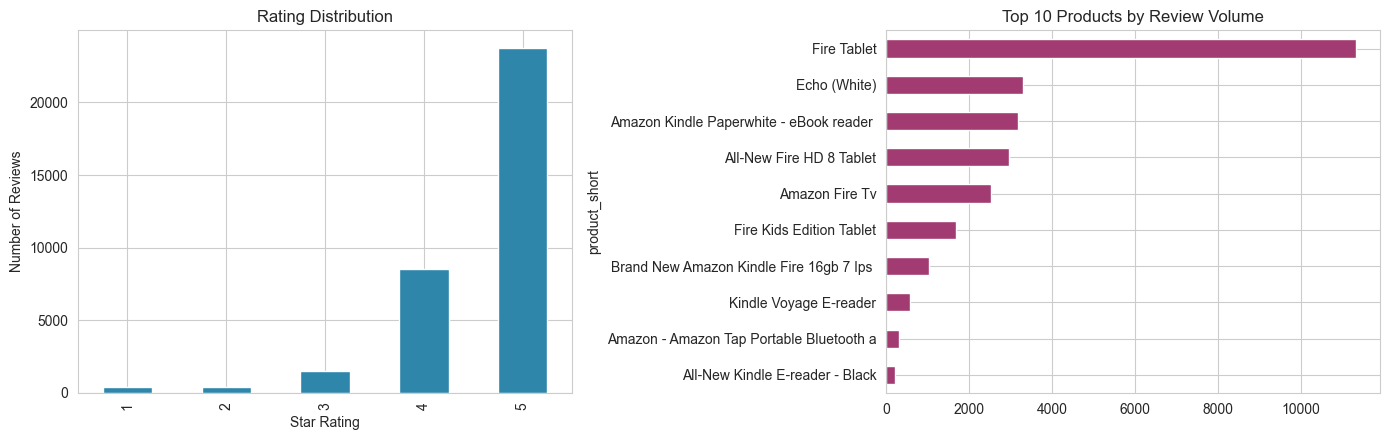

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

reviews["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#2E86AB")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")

top_products = reviews["product_short"].value_counts().head(10)
top_products.plot(kind="barh", ax=axes[1], color="#A23B72")
axes[1].set_title("Top 10 Products by Review Volume")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 4. Classical NLP Baseline — VADER Sentiment
Before reaching for an LLM, we establish a fast, free, deterministic baseline: VADER
(Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based sentiment scorer well-suited
to short, informal text like reviews. This lets us sanity-check that sentiment tracks star rating
and gives us a sentiment signal at zero marginal cost, before spending LLM calls on the deeper,
structured analysis.

In [4]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text):
    return analyzer.polarity_scores(str(text))["compound"]

reviews["vader_score"] = reviews["text"].apply(vader_compound)

# Sanity check: does VADER sentiment track star rating?
rating_vs_sentiment = reviews.groupby("rating")["vader_score"].mean()
print(rating_vs_sentiment)


rating
1    0.033261
2    0.066356
3    0.344790
4    0.607863
5    0.683538
Name: vader_score, dtype: float64


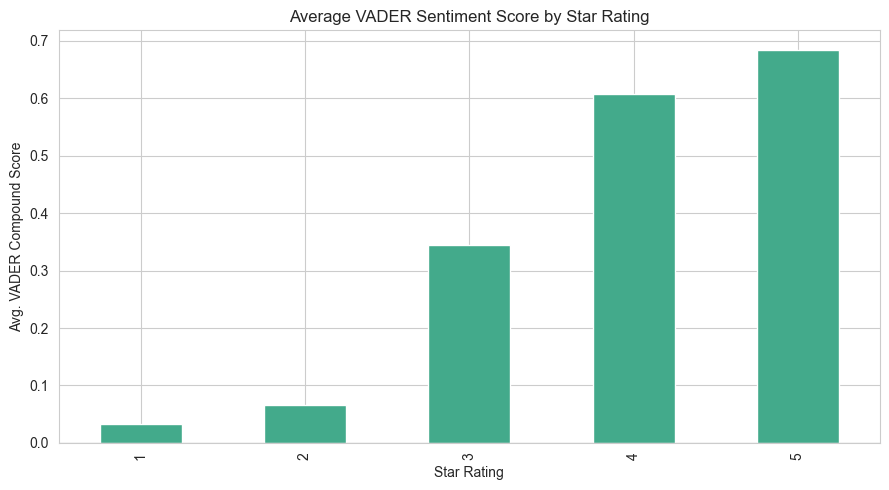

VADER tracks star rating monotonically, confirming it's a reasonable sentiment signal on this data.


In [5]:
fig, ax = plt.subplots()
rating_vs_sentiment.plot(kind="bar", ax=ax, color="#43AA8B")
ax.set_title("Average VADER Sentiment Score by Star Rating")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Avg. VADER Compound Score")
ax.axhline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()
print("VADER tracks star rating monotonically, confirming it's a reasonable sentiment signal on this data.")


## 5. GenAI Layer — Structured Insight Cards

VADER tells us *how positive* a review is, but not *why*. For that we use an LLM to read a sample
of reviews per product and extract structured themes: recurring praises, recurring complaints,
and a recommended action — the kind of summary a product/planning analyst would otherwise write
by hand after reading dozens of reviews.

We ask the model to return **strict JSON** so the output is directly usable in a dashboard rather
than free-form text that needs re-parsing.

In [6]:
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
GROQ_MODEL = "llama-3.3-70b-versatile"

client = None
if GROQ_API_KEY:
    from openai import OpenAI
    client = OpenAI(api_key=GROQ_API_KEY, base_url="https://api.groq.com/openai/v1")
    print("Groq client initialized — live LLM calls enabled.")
else:
    print("No GROQ_API_KEY found in environment — running in OFFLINE FALLBACK mode.")
    print("Get a free key at console.groq.com and run: export GROQ_API_KEY=your_key_here")


Groq client initialized — live LLM calls enabled.


In [7]:
INSIGHT_PROMPT = """You are a product analytics assistant. Read the customer reviews below for \
the product "{product}" and return ONLY valid JSON (no markdown, no commentary) in this exact shape:

{{
  "top_praises": ["...", "...", "..."],
  "top_complaints": ["...", "...", "..."],
  "recurring_themes": ["...", "...", "..."],
  "overall_sentiment": "positive" | "mixed" | "negative",
  "recommended_action": "one sentence, specific and actionable"
}}

Reviews:
{reviews_block}
"""


def _offline_fallback_summary(product, review_texts):
    """Lightweight keyword-frequency fallback used when no LLM key is configured.
    Not a substitute for the LLM version -- just keeps the notebook fully runnable."""
    stopwords = set("the a an and or is are was were this that it its i my we our for with on in to of very".split())
    words = re.findall(r"[a-zA-Z']+", " ".join(review_texts).lower())
    words = [w for w in words if w not in stopwords and len(w) > 3]
    common = [w for w, _ in Counter(words).most_common(8)]
    return {
        "top_praises": ["(offline mode -- set GROQ_API_KEY for real LLM-extracted praises)"],
        "top_complaints": ["(offline mode -- set GROQ_API_KEY for real LLM-extracted complaints)"],
        "recurring_themes": common,
        "overall_sentiment": "unknown (offline mode)",
        "recommended_action": "Set GROQ_API_KEY to generate a real LLM-based recommendation.",
    }


def summarize_product(product, review_texts, sample_size=25):
    sample = review_texts[:sample_size]
    if client is None:
        return _offline_fallback_summary(product, sample)

    reviews_block = "\n".join(f"- {t}" for t in sample)
    prompt = INSIGHT_PROMPT.format(product=product, reviews_block=reviews_block)

    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=600,
    )
    raw = response.choices[0].message.content.strip()
    raw = re.sub(r"^```json|```$", "", raw, flags=re.MULTILINE).strip()

    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"error": "Could not parse LLM output as JSON", "raw_output": raw}


In [8]:
# Run the insight pipeline on the top 6 products by review volume
top6 = reviews["product_short"].value_counts().head(6).index.tolist()

insight_cards = {}
for product in top6:
    texts = reviews.loc[reviews["product_short"] == product, "text"].tolist()
    insight_cards[product] = summarize_product(product, texts)
    print("Processed:", product)

insight_cards


Processed: Fire Tablet
Processed: Echo (White)
Processed: Amazon Kindle Paperwhite - eBook reader 
Processed: All-New Fire HD 8 Tablet
Processed: Amazon Fire Tv
Processed: Fire Kids Edition Tablet


{'Fire Tablet': {'top_praises': ['easy to use',
   'long battery life',
   'affordable',
   'portable',
   'great for reading'],
  'top_complaints': ['no backlight',
   'small screen size',
   'low screen resolution',
   'no light for night reading'],
  'recurring_themes': ['reading experience',
   'portability',
   'value for money',
   'ease of use'],
  'overall_sentiment': 'positive',
  'recommended_action': 'Consider adding a backlight feature to the Fire Tablet to improve the reading experience in low-light environments.'},
 'Echo (White)': {'top_praises': ['great value for the money',
   'fast and responsive',
   'good screen size and resolution',
   'easy to use and navigate',
   'perfect for entertainment and reading'],
  'top_complaints': ['ads on the lock screen',
   'slow performance with certain games',
   'limited storage space',
   'no support for certain apps'],
  'recurring_themes': ['value for money',
   'ease of use',
   'entertainment and media consumption',
   'port

## 6. Display Insight Cards

In [9]:
for product, card in insight_cards.items():
    print("=" * 90)
    print(product)
    print("=" * 90)
    print(json.dumps(card, indent=2))
    print()


Fire Tablet
{
  "top_praises": [
    "easy to use",
    "long battery life",
    "affordable",
    "portable",
    "great for reading"
  ],
  "top_complaints": [
    "no backlight",
    "small screen size",
    "low screen resolution",
    "no light for night reading"
  ],
  "recurring_themes": [
    "reading experience",
    "portability",
    "value for money",
    "ease of use"
  ],
  "overall_sentiment": "positive",
  "recommended_action": "Consider adding a backlight feature to the Fire Tablet to improve the reading experience in low-light environments."
}

Echo (White)
{
  "top_praises": [
    "great value for the money",
    "fast and responsive",
    "good screen size and resolution",
    "easy to use and navigate",
    "perfect for entertainment and reading"
  ],
  "top_complaints": [
    "ads on the lock screen",
    "slow performance with certain games",
    "limited storage space",
    "no support for certain apps"
  ],
  "recurring_themes": [
    "value for money",
    "ea

## 7. Sentiment Signal vs. LLM Theme Extraction — Side by Side
Combining both layers gives a fuller picture: VADER gives a fast quantitative sentiment score
per review, while the LLM gives qualitative structure (specific praises/complaints/themes) that
a quantitative score alone can't. Neither layer replaces the other.

In [10]:
summary_rows = []
for product in top6:
    subset = reviews[reviews["product_short"] == product]
    summary_rows.append({
        "product": product,
        "n_reviews": len(subset),
        "avg_rating": subset["rating"].mean(),
        "avg_vader_score": subset["vader_score"].mean(),
        "llm_sentiment": insight_cards[product].get("overall_sentiment", "n/a"),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,product,n_reviews,avg_rating,avg_vader_score,llm_sentiment
0,Fire Tablet,11330,4.458076,0.628821,positive
1,Echo (White),3310,4.645317,0.679598,positive
2,Amazon Kindle Paperwhite - eBook reader,3176,4.755038,0.677028,positive
3,All-New Fire HD 8 Tablet,2960,4.585811,0.630001,positive
4,Amazon Fire Tv,2528,4.650316,0.694530,positive
5,Fire Kids Edition Tablet,1685,4.510386,0.640167,positive


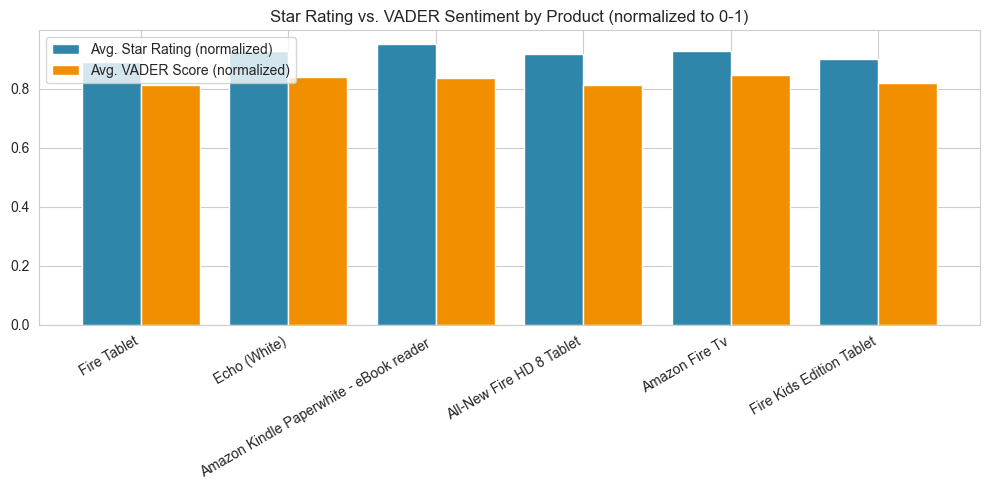

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary_df))
ax.bar(x - 0.2, summary_df["avg_rating"] / 5, width=0.4, label="Avg. Star Rating (normalized)", color="#2E86AB")
ax.bar(x + 0.2, (summary_df["avg_vader_score"] + 1) / 2, width=0.4, label="Avg. VADER Score (normalized)", color="#F18F01")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["product"], rotation=30, ha="right")
ax.set_title("Star Rating vs. VADER Sentiment by Product (normalized to 0-1)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Export Results

Save insight cards + summary table for the companion Streamlit dashboard.

In [12]:
with open("../outputs/product_insight_cards.json", "w") as f:
    json.dump(insight_cards, f, indent=2)

summary_df.to_csv("../outputs/product_sentiment_summary.csv", index=False)

# Also export the full per-review VADER scores (used for the dashboard's live-analysis demo)
reviews[["product_short", "rating", "vader_score", "text"]].to_csv(
    "../outputs/reviews_with_sentiment.csv", index=False
)
print("Exported insight cards, sentiment summary, and per-review scores.")


Exported insight cards, sentiment summary, and per-review scores.


## 9. Key Takeaways
- Built a two-layer NLP pipeline: a **classical VADER sentiment baseline** (fast, free, validated
  against star ratings) plus an **LLM-based structured extraction layer** that turns raw review
  text into product-team-ready insight cards (praises, complaints, themes, recommended action).
- Designed the LLM layer to return **strict JSON**, making it directly consumable by a dashboard
  rather than free text requiring manual re-reading.
- Wired the pipeline to **Groq's free API tier** (no cost, no credit card) so the project is fully
  reproducible by anyone, and built a **graceful offline fallback** so the notebook always runs
  end-to-end even without an API key configured.
- Exported results to power an interactive Streamlit dashboard (`app/dashboard.py`) including a
  live "paste your own review" analysis box.
